In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../shared").resolve()))
sys.path.insert(0, str(Path(".").resolve()))

from constants import (
    ARM_LINK,
    CAPTIONS_PATH,
    CARTESIAN_CONTROL_CACHE_PATH,
    CC_A_MAX_EL_NEG,
    CC_A_MAX_EL_POS,
    CC_A_MAX_SH_NEG,
    CC_A_MAX_SH_POS,
    CC_ABLATION_RESULTS_DIR,
    CC_AMP_REG,
    CC_BAND_CHANNELS,
    CC_CONSTRAIN_ELBOW,
    CC_DIST_THRESH,
    CC_EL_THRESH,
    CC_N_R,
    CC_N_THETA,
    CC_OPEN_LOOP_OFFSET,
    CC_OPTIMAL_PARAMS_PATH,
    CC_Q_INT,
    CC_Q_TRACK,
    CC_R_EFFORT,
    CC_SH_THRESH,
    CC_SH_DRIFT_THRESH,
    CC_T,
    CC_TARGET_R_MAX,
    CC_TARGET_R_MIN,
    ERA_EM_4_PATH,
    FIGURES_PATH,
    MAX_DELTA,
)
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from cartesian_control import run_cartesian_control, aggregate_seed_metrics
from cartesian_control_ablation_control_mode import (
    NOTEBOOK_GITHUB_URL,
    make_control_mode_figure,
)

In [2]:
# ── 2. Constants ──────────────────────────────────────────────────────────────
ABLATION_SEEDS = list(range(10))   # 10 seeds sufficient for ablations
CONDITIONS = {
    "Open-loop": {"use_lqi": False},
    "LQI":       {"use_lqi": True},
}

In [3]:
# ── 3. Derived variables ──────────────────────────────────────────────────────
if CC_OPTIMAL_PARAMS_PATH.exists():
    with open(CC_OPTIMAL_PARAMS_PATH) as fh:
        optimal_params = json.load(fh)
    print(f"Loaded optimal params from {CC_OPTIMAL_PARAMS_PATH.name}")
else:
    optimal_params = {}
    print("Optimal params not found — using defaults from constants.py")

CC_ABLATION_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

base_params = dict(
    cache_path=CARTESIAN_CONTROL_CACHE_PATH,
    estimator_path=ERA_EM_4_PATH,
    T=CC_T, n_r=CC_N_R, n_theta=CC_N_THETA,
    target_r_min=CC_TARGET_R_MIN, target_r_max=CC_TARGET_R_MAX,
    dist_thresh=CC_DIST_THRESH, arm_link=ARM_LINK, max_delta=MAX_DELTA,
    q_track=CC_Q_TRACK, r_effort=CC_R_EFFORT, q_int=CC_Q_INT,
    el_thresh=CC_EL_THRESH, sh_thresh=CC_SH_THRESH,
    sh_drift_thresh=CC_SH_DRIFT_THRESH,
    a_max_sh_pos=CC_A_MAX_SH_POS, a_max_sh_neg=CC_A_MAX_SH_NEG,
    a_max_el_pos=CC_A_MAX_EL_POS, a_max_el_neg=CC_A_MAX_EL_NEG,
    amp_reg=CC_AMP_REG,
    constrain_elbow=CC_CONSTRAIN_ELBOW,
    band_channels=CC_BAND_CHANNELS, open_loop_offset=CC_OPEN_LOOP_OFFSET,
)

Loaded optimal params from cc_optimal_params.json


In [4]:
# ── 4. Simulation ─────────────────────────────────────────────────────────────
ablation_results = {}
for cond_name, overrides in CONDITIONS.items():
    per_seed: list = []
    for seed in ABLATION_SEEDS:
        slug = cond_name.lower().replace("-", "_").replace(" ", "_")
        results, _, _ = run_cartesian_control(
            **{**base_params, **optimal_params, **overrides},
            demo_seed=seed,
            results_path=CC_ABLATION_RESULTS_DIR / f"ctrl_mode_{slug}_{seed}.pkl",
        )
        per_seed.append(results)
    ablation_results[cond_name] = aggregate_seed_metrics(
        per_seed, T=CC_T, dist_thresh=CC_DIST_THRESH
    )

print("\nAblation summary (mean ± SD across seeds):")
for cond, agg in ablation_results.items():
    fd = agg["final_dist"]
    fr = agg["frac_in_sector"]
    print(f"  {cond:<14}: final_dist={fd.mean():.2f}±{fd.std():.2f}  frac={fr.mean():.3f}±{fr.std():.3f}")

Loading cached results from ctrl_mode_open_loop_0.pkl
Loading cached results from ctrl_mode_open_loop_1.pkl
Loading cached results from ctrl_mode_open_loop_2.pkl
Loading cached results from ctrl_mode_open_loop_3.pkl
Loading cached results from ctrl_mode_open_loop_4.pkl
Loading cached results from ctrl_mode_open_loop_5.pkl
Loading cached results from ctrl_mode_open_loop_6.pkl
Loading cached results from ctrl_mode_open_loop_7.pkl
Loading cached results from ctrl_mode_open_loop_8.pkl
Loading cached results from ctrl_mode_open_loop_9.pkl
Loading cached results from ctrl_mode_lqi_0.pkl
Loading cached results from ctrl_mode_lqi_1.pkl
Loading cached results from ctrl_mode_lqi_2.pkl
Loading cached results from ctrl_mode_lqi_3.pkl
Loading cached results from ctrl_mode_lqi_4.pkl
Loading cached results from ctrl_mode_lqi_5.pkl
Loading cached results from ctrl_mode_lqi_6.pkl
Loading cached results from ctrl_mode_lqi_7.pkl
Loading cached results from ctrl_mode_lqi_8.pkl
Loading cached results from 

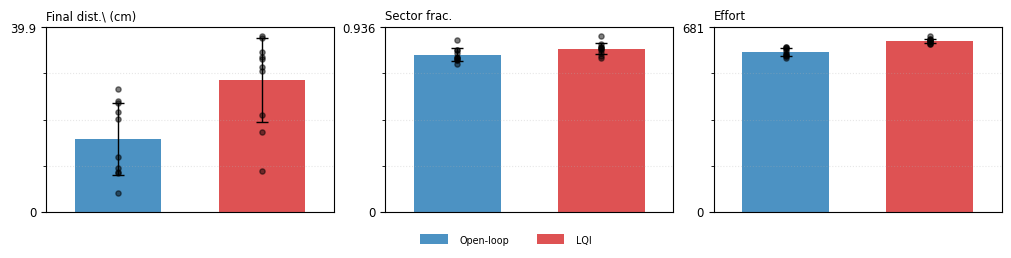

In [5]:
# ── 5. Display ────────────────────────────────────────────────────────────────
configure_screen()
fig = make_control_mode_figure(ablation_results, figsize=(10.0, 2.5))
apply_figure_style(fig)
plt.show()

In [6]:
# ── 6. PGF export ─────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 0.50
FIG_HEIGHT_FRAC = 0.14

configure_pgf()
fig = make_control_mode_figure(
    ablation_results,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "cartesian_control_ablation_control_mode.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/cartesian_control_ablation_control_mode.pgf


In [7]:
# ── 7. Caption ────────────────────────────────────────────────────────────────
n_seeds  = len(ABLATION_SEEDS)
n_trials = CC_N_R * CC_N_THETA

ol_fd = ablation_results["Open-loop"]["final_dist"]
lq_fd = ablation_results["LQI"]["final_dist"]
ol_fr = ablation_results["Open-loop"]["frac_in_sector"]
lq_fr = ablation_results["LQI"]["frac_in_sector"]

caption = (
    r"Ablation comparing open-loop (sinusoidal drive) and closed-loop "
    r"LQI control modes on "
    f"{n_trials} targets across $N={n_seeds}$ Brain seeds "
    f"($T={CC_T}$ steps). "
    r"Bars show mean across seeds; error bars and dots show ±\,1\,SD and "
    r"individual seed means, respectively. "
    r"Four metrics are shown: final distance to target, sector fraction, "
    r"time-to-threshold, and control effort. "
    f"Open-loop final distance: ${ol_fd.mean():.1f} \\pm {ol_fd.std():.1f}$\\,cm; "
    f"LQI: ${lq_fd.mean():.1f} \\pm {lq_fd.std():.1f}$\\,cm."
)

save_caption(
    CAPTIONS_PATH / "cartesian_control_ablation_control_mode.tex",
    caption, NOTEBOOK_GITHUB_URL,
)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/cartesian_control_ablation_control_mode.tex
Ablation comparing open-loop (sinusoidal drive) and closed-loop LQI control modes on 24 targets across $N=10$ Brain seeds ($T=1000$ steps). Bars show mean across seeds; error bars and dots show ±\,1\,SD and individual seed means, respectively. Four metrics are shown: final distance to target, sector fraction, time-to-threshold, and control effort. Open-loop final distance: $15.8 \pm 7.7$\,cm; LQI: $28.5 \pm 9.2$\,cm.
